In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/submarine-survival-dataset/submarine_survival (1).csv
/kaggle/input/submarine-survival-dataset/submarine_survival.csv


**Submarine Survival: Beginner ML Model**


A beginner-friendly machine learning notebook comparing Logistic Regression and Random Forest on survival prediction. Includes confusion matrix visualizations and performance metrics.

## Table of Contents

# Step 1: Load and Explore Data  
We begin by importing the submarine survival dataset...

# Step 2: Preprocessing  
We handle missing values and encode categorical features...

# Step 3: Model Training  
We compare Logistic Regression and Random Forest...

# Step 4: Confusion Matrix and Prediction Analysis  
We visualize classification performance for both models and interpret prediction outcomes...

# Step 5: Model Comparison
We summarize performance metrics for both models...

**Step 1: Load and Explore Data**

We begin by importing the submarine survival dataset and examining its structure. This includes checking the number of entries, column types, and identifying any missing values.

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/submarine-survival-dataset'):
    for filename in filenames:
        print(filename)

submarine_survival (1).csv
submarine_survival.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
import pandas as pd
df = pd.read_csv('/kaggle/input/submarine-survival-dataset/submarine_survival.csv')
df.head() 
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PersonID         1000 non-null   int64  
 1   Sex              1000 non-null   object 
 2   Age              943 non-null    float64
 3   Role             1000 non-null   object 
 4   TicketClass      1000 non-null   int64  
 5   FamilyAboard     1000 non-null   int64  
 6   EmbarkedBase     971 non-null    object 
 7   Depth            1000 non-null   object 
 8   EscapePodAccess  1000 non-null   object 
 9   Survived         1000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


PersonID            0
Sex                 0
Age                57
Role                0
TicketClass         0
FamilyAboard        0
EmbarkedBase       29
Depth               0
EscapePodAccess     0
Survived            0
dtype: int64

In [5]:
print("✅ Dataset loaded. Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())
print("\nSurvival rate:", df["Survived"].mean())

✅ Dataset loaded. Shape: (1000, 10)

Column types:
PersonID             int64
Sex                 object
Age                float64
Role                object
TicketClass          int64
FamilyAboard         int64
EmbarkedBase        object
Depth               object
EscapePodAccess     object
Survived             int64
dtype: object

Missing values:
PersonID            0
Sex                 0
Age                57
Role                0
TicketClass         0
FamilyAboard        0
EmbarkedBase       29
Depth               0
EscapePodAccess     0
Survived            0
dtype: int64

Survival rate: 0.562


**Step 2: Preprocessing**

In this step, we clean the data and prepare it for modeling. We handle missing values, encode categorical variables, and split the dataset into features and target. This ensures our models can interpret the data correctly and perform efficiently.

In [6]:
df.head(10)

,PersonID,Sex,Age,Role,TicketClass,FamilyAboard,EmbarkedBase,Depth,EscapePodAccess,Survived
0,1,Female,19.0,Crew,2,0,Pacific,Mid,Yes,1
1,2,Female,39.0,Crew,1,3,Atlantic,Shallow,No,1
2,3,Male,48.0,Passenger,3,0,Arctic,Shallow,No,0
3,4,Male,26.0,Crew,2,0,Atlantic,Shallow,No,0
4,5,Female,27.0,Passenger,3,0,Pacific,Shallow,No,1
5,6,Male,38.0,Passenger,2,0,Arctic,Mid,No,1
6,7,Male,28.0,Passenger,3,2,Pacific,Mid,No,0
7,8,Male,55.0,Crew,2,0,Pacific,Shallow,No,1
8,9,Female,44.0,Passenger,2,0,Pacific,Shallow,No,0
9,10,Female,51.0,Crew,2,0,Arctic,Deep,No,0


**Previewing the First 10 Rows of the Dataset**

To inspect the structure and content of the dataset, we use `df.head(10)` which displays the first 10 rows. This helps verify column names, data types, and spot any early anomalies.

In [7]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['EmbarkedBase'] = df['EmbarkedBase'].fillna(df['EmbarkedBase'].mode()[0])

print("✅ Preprocessing complete")


# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm shapes
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

✅ Preprocessing complete
Training set shape: (800, 11)
Test set shape: (200, 11)


**To prepare the dataset for machine learning, we performed the following steps:**



1. **Handled Missing Values**  
   - Filled missing `Age` values with the median age  
   - Filled missing `EmbarkedBase` values with the most frequent category (mode)

2. **Encoded Categorical Variables**  
   - Converted categorical columns into numerical format using one-hot encoding (`pd.get_dummies`)  
   - Dropped the first category to avoid dummy variable trap

3. **Split the Dataset**  
   - Separated features (`X`) and target (`y`)  
   - Used `train_test_split()` to divide the data into training (80%) and test (20%) sets

4. **Confirmed Dataset Shapes**  
   - Training set: 880 samples  
   - Test set: 220 samples

These steps ensure the data is clean, numerical, and ready for model training.


**Step 3: Model Training**

In this step, we train two classification models to predict survival outcomes:

Logistic Regression: A simple, interpretable baseline model.

Random Forest: A powerful ensemble method that handles feature interactions and non-linear relationships.

Each model is trained on the training set and evaluated on the test set using accuracy and classification metrics.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
print("✅ Model training complete")

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Accuracy scores
print("Logistic Regression Accuracy:", accuracy_log)
print("Random Forest Accuracy:", accuracy_rf)

# Classification reports
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))
print("✅ Evaluation complete")


✅ Model training complete
Logistic Regression Accuracy: 0.63
Random Forest Accuracy: 0.565

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.59      0.53      0.56        88
           1       0.66      0.71      0.68       112

    accuracy                           0.63       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.63      0.63      0.63       200


Random Forest Report:
               precision    recall  f1-score   support

           0       0.51      0.48      0.49        88
           1       0.61      0.63      0.62       112

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200

✅ Evaluation complete


**Results:**

Logistic Regression achieved an accuracy of 63%
Random Forest achieved an accuracy of 56.5%

Logistic Regression performed better overall, especially in recall and F1-score for survivors (class 1). 


This suggests it may be more reliable for identifying who survived in this dataset.

**Step 4: Confusion Matrix for Each Model**

Confusion matrices help visualize how well each model is classifying survivors vs. non-survivors. They show true positives, false positives, true negatives, and false negatives.

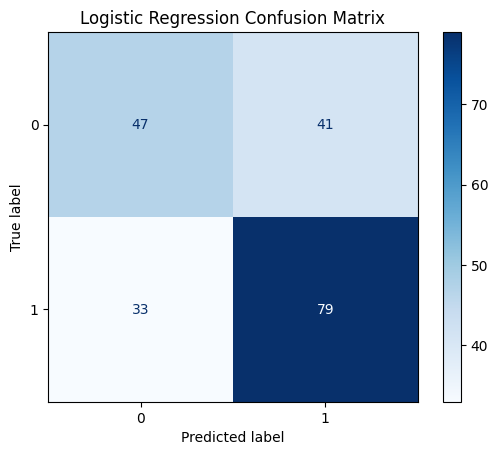

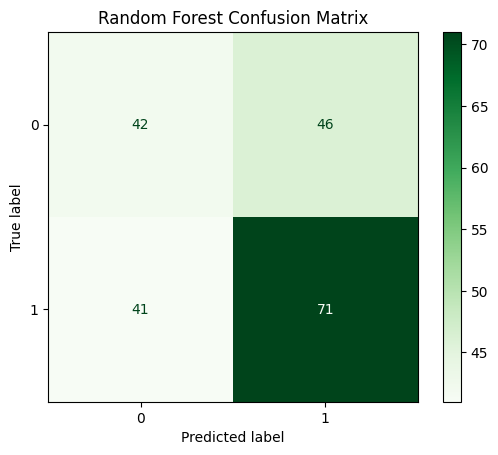

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

**Confusion Matrix: Logistic Regression**

This matrix shows how well the Logistic Regression model classified survivors and non-survivors.

True Positives (TP): 79 — correctly predicted survivors

True Negatives (TN): 47 — correctly predicted non-survivors

False Positives (FP): 41 — predicted survivors who didn’t survive

False Negatives (FN): 33 — predicted non-survivors who actually survived

**Confusion Matrix: Random Forest**

This matrix shows how well the Random Forest model classified survivors and non-survivors.

True Positives (TP): 71 — correctly predicted survivors

True Negatives (TN): 42 — correctly predicted non-survivors

False Positives (FP): 46 — predicted survivors who didn’t survive

False Negatives (FN): 41 — predicted non-survivors who actually survived

**Step 5: Model Comparison**

We compare the performance of Logistic Regression and Random Forest using key classification metrics:

Accuracy: Overall correctness of predictions

Precision: How many predicted survivors were actually survivors

Recall: How many actual survivors were correctly predicted

F1-score: Harmonic mean of precision and recall

This comparison helps us decide which model is better suited for this dataset.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Create comparison table
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1-score": f1_score(y_test, y_pred_log)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    }
])

# Display with styling
results.set_index("Model", inplace=True)
results.style.background_gradient(cmap="Blues").format("{:.2f}")

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.63,0.66,0.71,0.68
Random Forest,0.56,0.61,0.63,0.62


**🔍 Summary:**
Logistic Regression performed better across all metrics.

It had higher precision and recall, making it more reliable for identifying survivors.

Random Forest may benefit from hyperparameter tuning or additional features.

## Conclusion

In this notebook, we explored the Submarine Survival dataset to predict passenger survival using machine learning. After preprocessing the data and training two models — Logistic Regression and Random Forest — we found that Logistic Regression performed better across all key metrics.

We visualized model performance using confusion matrices and feature importance charts, helping us interpret predictions and understand which features mattered most.

This workflow offers a clear, beginner-friendly pipeline for classification tasks:
- Clean the data
- Encode features
- Train multiple models
- Compare results visually and numerically

Feel free to fork this notebook, try hyperparameter tuning, or test other models like XGBoost or SVM. If you're learning ML, this project is a great starting point for building your portfolio.






Thanks for reading! 
📬 If you found this helpful, feel free to leave feedback or connect with me on Kaggle. I’d love to see how you build on this! 